# Diminos Case Study

## Objective

**As a freelance data scientist, the objective is to:**
- Analyze delivery performance
- Validate SLA compliance
- Identify risks and improvement areas
- Share actionable business insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("diminos_data.csv")
df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   order_id            15000 non-null  int64 
 1   order_placed_at     15000 non-null  object
 2   order_delivered_at  15000 non-null  object
dtypes: int64(1), object(2)
memory usage: 351.7+ KB


,order_id
count,1.500000e+04
mean,1.530610e+06
std,4.330271e+03
min,1.523111e+06
25%,1.526861e+06
50%,1.530610e+06
75%,1.534360e+06
max,1.538110e+06


## Dataset Description

**The dataset contains 1500 pizza orders with the following columns:**

 - **order_id** – Unique order identifier
 - **order_placed_at** – Timestamp when order was placed
 - **order_delivered_at** – Timestamp when order was delivered

In [3]:
df = pd.read_csv("diminos_data.csv")

# Convert columns to datetime (safe even if already converted)
df["order_placed_at"] = pd.to_datetime(df["order_placed_at"])
df["order_delivered_at"] = pd.to_datetime(df["order_delivered_at"])

df.head()

,order_id,order_placed_at,order_delivered_at
0,1523111,2023-03-01 00:00:59,2023-03-01 00:18:07.443132
1,1523112,2023-03-01 00:03:59,2023-03-01 00:19:34.925241
2,1523113,2023-03-01 00:07:22,2023-03-01 00:22:28.291385
3,1523114,2023-03-01 00:07:47,2023-03-01 00:46:19.019399
4,1523115,2023-03-01 00:09:03,2023-03-01 00:25:13.619056


In [4]:
df["delivery_time_minutes"] = (
    df["order_delivered_at"] - df["order_placed_at"]
).dt.total_seconds() / 60

df[["order_placed_at", "order_delivered_at", "delivery_time_minutes"]].head()


,order_placed_at,order_delivered_at,delivery_time_minutes
0,2023-03-01 00:00:59,2023-03-01 00:18:07.443132,17.140719
1,2023-03-01 00:03:59,2023-03-01 00:19:34.925241,15.598754
2,2023-03-01 00:07:22,2023-03-01 00:22:28.291385,15.104856
3,2023-03-01 00:07:47,2023-03-01 00:46:19.019399,38.533657
4,2023-03-01 00:09:03,2023-03-01 00:25:13.619056,16.176984


In [5]:
df["delivery_time_minutes"].describe()
df[df["delivery_time_minutes"] < 0]


,order_id,order_placed_at,order_delivered_at,delivery_time_minutes


In [6]:
p95 = df["delivery_time_minutes"].quantile(0.95)
p95


np.float64(27.261043996666658)

In [7]:
if p95 < 31:
    print(f"SLA MET: 95th percentile = {p95:.2f} minutes")
else:
    print(f"SLA BREACHED: 95th percentile = {p95:.2f} minutes")


SLA MET: 95th percentile = 27.26 minutes


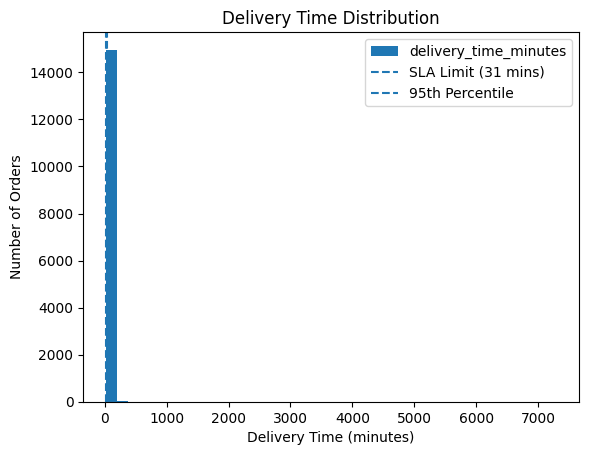

In [8]:
df["delivery_time_minutes"].plot(kind="hist", bins=40)
plt.axvline(31, linestyle="--", label="SLA Limit (31 mins)")
plt.axvline(p95, linestyle="--", label="95th Percentile")
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Number of Orders")
plt.legend()
plt.show()


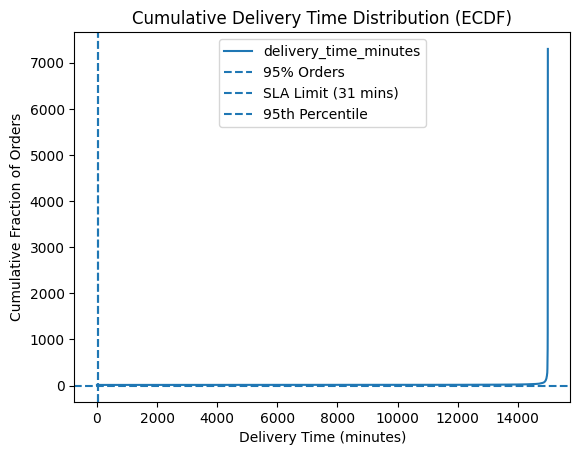

In [9]:
df["delivery_time_minutes"].sort_values().reset_index(drop=True) \
  .plot(kind="line")

plt.axhline(0.95, linestyle="--", label="95% Orders")
plt.axvline(31, linestyle="--", label="SLA Limit (31 mins)")
plt.axvline(p95, linestyle="--", label="95th Percentile")

plt.title("Cumulative Delivery Time Distribution (ECDF)")
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Cumulative Fraction of Orders")
plt.legend()
plt.show()



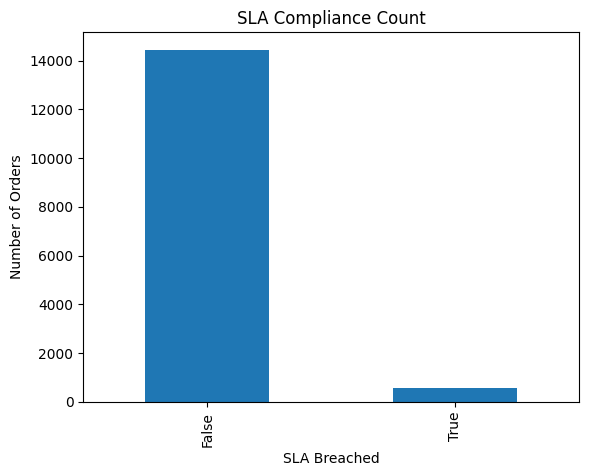

In [10]:
(df["delivery_time_minutes"] > 31).value_counts().plot(kind="bar")

plt.title("SLA Compliance Count")
plt.xlabel("SLA Breached")
plt.ylabel("Number of Orders")
plt.show()


In [11]:
breach_rate = (df["delivery_time_minutes"] > 31).mean() * 100
breach_rate

np.float64(3.713333333333333)

## Key Insights

- 95th percentile delivery time = 27.26 minutes (SLA met)
- 3.7% orders breach SLA, mainly due to operational delays
- Majority of deliveries occur between 20–30 minutes


### Recommendations for Kanav

- Increase delivery staff during peak hours

- Pre-prepare high-demand items

- Monitor late-night orders closely

- Use real-time alerts for delayed orders

## Conclusion

Kanav's Diminos store meets the SLA requirements set by Diminos. With minimal operational improvements, the store can further reduce SLA breaches and maximize profitability while retaining the franchise. Franchise is safe and operationally healthy.